# Sales and Revenue Performance Dashboard — Exploratory & KPI Analysis

This notebook performs the exploratory data analysis and KPI calculations that
feed the Power BI-style dashboard for this project. It complements the SQL
scripts in `sql/` — the same metrics are computed here in pandas so the
analysis is reproducible without a database engine.

**Workflow covered in this notebook:**
1. Load the cleaned dataset
2. Headline KPIs (total sales, profit, margin, AOV)
3. Regional performance
4. Category / sub-category performance
5. Monthly revenue trend
6. Top products and customers
7. Key insights summary


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.dpi"] = 110
pd.options.display.float_format = "{:,.2f}".format

df = pd.read_csv("../data/processed/sales_data_clean.csv", parse_dates=["order_date", "ship_date"])
df.shape

(9802, 23)

In [2]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,region,city,state,...,product_id,product_name,sales,quantity,discount,profit,profit_margin,order_year,order_month,order_year_month
0,ORD-2023-103710,2022-11-30,2022-07-12,Same Day,CUST-00838,Sofia Kim,Consumer,South,Charlotte,North Carolina,...,OFF-BIN-2071,View Binder,821.31,7,0.00,269.05,0.33,2022,11,2022-11
1,ORD-2021-105313,2022-08-07,2022-08-08,Standard Class,CUST-03804,Jennifer Johnson,Consumer,East,Philadelphia,Pennsylvania,...,TEC-ACC-6995,Laptop Stand,"5,697.55",5,0.30,336.28,0.06,2022,8,2022-08
2,ORD-2022-105479,2021-10-11,2021-10-15,Standard Class,CUST-03570,Patricia Chen,Home Office,South,Miami,Florida,...,OFF-BIN-1180,Heavy-Duty Binder,249.37,4,0.10,25.14,0.10,2021,10,2021-10
3,ORD-2023-101253,2022-04-06,2022-04-07,Same Day,CUST-01153,Maria Miller,Home Office,South,Charlotte,North Carolina,...,FUR-CHA-9053,Stackable Conference Chair,342.31,1,0.15,-35.64,-0.10,2022,4,2022-04
4,ORD-2023-109668,2023-03-13,2023-03-17,First Class,CUST-00963,Maria Davis,Home Office,West,Seattle,Washington,...,OFF-STO-4246,Metal Storage Cabinet,86.27,3,0.10,25.64,0.30,2023,3,2023-03


## 1. Headline KPIs

In [3]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
overall_margin = total_profit / total_sales
total_orders = df["order_id"].nunique()
avg_order_value = total_sales / total_orders
total_customers = df["customer_id"].nunique()

kpis = pd.Series({
    "Total Sales": f"${total_sales:,.0f}",
    "Total Profit": f"${total_profit:,.0f}",
    "Overall Profit Margin": f"{overall_margin:.1%}",
    "Total Orders": f"{total_orders:,}",
    "Avg Order Value": f"${avg_order_value:,.2f}",
    "Total Customers": f"{total_customers:,}",
})
kpis

Total Sales              $23,546,385
Total Profit              $2,641,984
Overall Profit Margin          11.2%
Total Orders                   9,800
Avg Order Value            $2,402.69
Total Customers                  248
dtype: object

## 2. Regional Performance

In [4]:
regional = (
    df.groupby("region")
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .assign(profit_margin=lambda d: d["total_profit"] / d["total_sales"])
      .sort_values("total_sales", ascending=False)
)
regional

,total_sales,total_profit,profit_margin
region,,,
West,"6,157,931.23","701,621.24",0.11
South,"5,868,048.62","648,036.62",0.11
East,"5,774,633.43","658,862.42",0.11
Central,"5,745,771.57","633,463.97",0.11


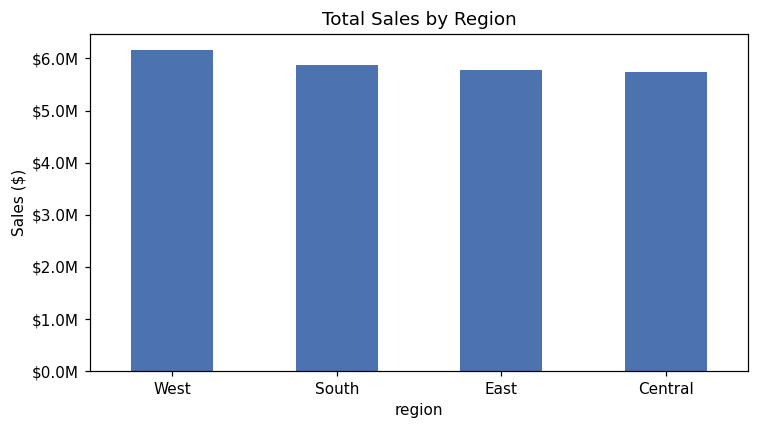

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
regional["total_sales"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Total Sales by Region")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/sales_by_region.png")
plt.show()

## 3. Category & Sub-Category Performance

In [6]:
category = (
    df.groupby("category")
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .assign(profit_margin=lambda d: d["total_profit"] / d["total_sales"])
      .sort_values("total_sales", ascending=False)
)
category

,total_sales,total_profit,profit_margin
category,,,
Technology,"15,272,949.80","1,926,119.10",0.13
Furniture,"6,722,403.04","369,678.21",0.05
Office Supplies,"1,551,032.01","346,186.95",0.22


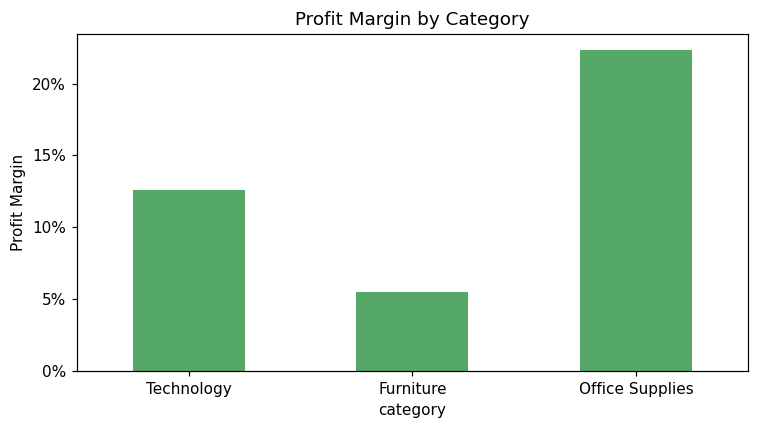

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
category["profit_margin"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Profit Margin by Category")
ax.set_ylabel("Profit Margin")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/profit_margin_by_category.png")
plt.show()

## 4. Monthly Revenue Trend

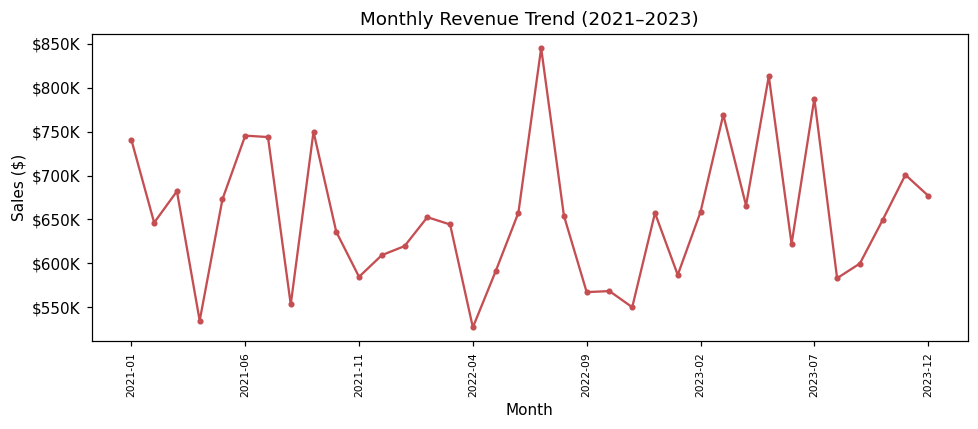

In [8]:
monthly = df.groupby("order_year_month").agg(total_sales=("sales", "sum")).sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
monthly["total_sales"].plot(ax=ax, color="#C44E52", marker="o", markersize=3)
ax.set_title("Monthly Revenue Trend (2021–2023)")
ax.set_ylabel("Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_xlabel("Month")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig("../images/monthly_revenue_trend.png")
plt.show()

## 5. Top 10 Products by Revenue

In [9]:
top_products = (
    df.groupby("product_name")
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"), units_sold=("quantity", "sum"))
      .sort_values("total_sales", ascending=False)
      .head(10)
)
top_products

,total_sales,total_profit,units_sold
product_name,,,
Office Copier Pro,"1,892,565.29","237,991.07",2452
Desktop Copier,"1,859,653.84","226,318.27",2252
Laser Printer,"1,518,391.25","187,367.28",1856
Laptop Stand,"1,350,216.84","177,926.57",1669
Fax Machine,"1,333,713.70","174,745.92",1616
Label Maker,"1,319,393.63","168,709.35",1579
VoIP Desk Phone,"1,284,388.02","172,930.84",1597
Smartphone X200,"1,235,766.58","148,136.90",1599
Wireless Mouse,"1,208,471.81","164,492.85",1476


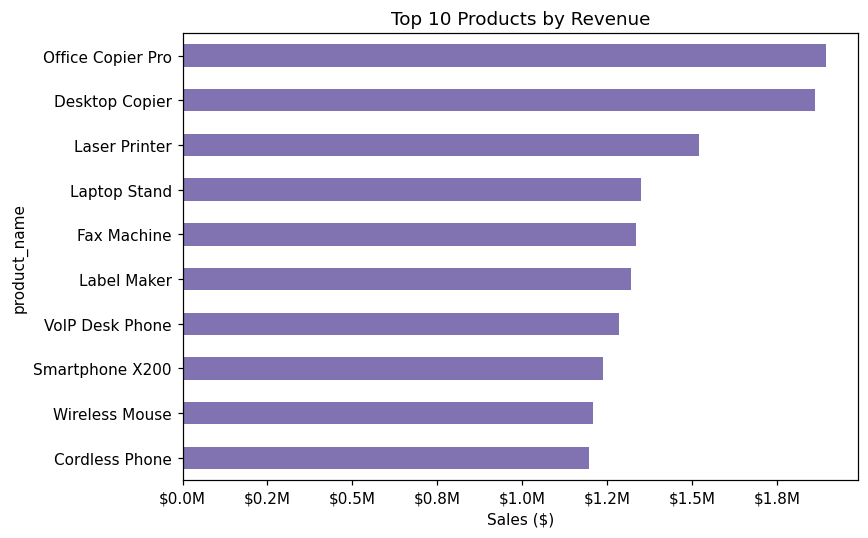

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
top_products["total_sales"].sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Sales ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("../images/top_10_products.png")
plt.show()

## 6. High-Volume, Low-Margin Products\n\nProducts with above-average sales volume but a profit margin under 5% — candidates for pricing or discount policy review.

In [11]:
volume_threshold = df["sales"].mean() * 20
by_product = (
    df.groupby("product_name")
      .agg(total_sales=("sales", "sum"), total_profit=("profit", "sum"))
      .assign(profit_margin=lambda d: d["total_profit"] / d["total_sales"])
)
low_margin_high_volume = by_product[
    (by_product["total_sales"] > volume_threshold) & (by_product["profit_margin"] < 0.05)
].sort_values("total_sales", ascending=False)
low_margin_high_volume

,total_sales,total_profit,profit_margin
product_name,,,
5-Shelf Bookcase,"596,478.07","26,304.62",0.04
Adjustable Height Desk,"473,642.42","19,844.59",0.04
Desk Lamp,"427,724.76","19,416.21",0.05
Executive Leather Chair,"409,855.39","16,082.36",0.04


## 7. Top 10 Customers by Lifetime Revenue

In [12]:
top_customers = (
    df.groupby(["customer_id", "customer_name", "segment"])
      .agg(lifetime_sales=("sales", "sum"), lifetime_profit=("profit", "sum"), total_orders=("order_id", "nunique"))
      .sort_values("lifetime_sales", ascending=False)
      .head(10)
      .reset_index()
)
top_customers

,customer_id,customer_name,segment,lifetime_sales,lifetime_profit,total_orders
0,CUST-01265,Robert Martinez,Corporate,"106,207.20","8,398.91",28
1,CUST-03884,William Anderson,Consumer,"87,881.66","8,251.69",20
2,CUST-02419,Robert Kim,Corporate,"82,077.27","10,965.97",19
3,CUST-01632,Priya Kim,Consumer,"81,596.71","12,282.65",21
4,CUST-04851,Carlos Patel,Home Office,"73,047.84","6,205.69",21
5,CUST-04375,Sofia Johnson,Corporate,"72,944.96","9,852.42",18
6,CUST-03221,Wei Kim,Corporate,"70,984.88","6,004.58",13
7,CUST-01728,Patricia Miller,Corporate,"70,351.63","8,717.57",17
8,CUST-02178,Jennifer Kim,Home Office,"69,186.37","9,358.11",17
9,CUST-02922,Michael Patel,Consumer,"67,999.45","9,195.09",15


## 8. Key Insights Summary

- **Technology drives revenue.** Technology accounts for the largest share of total sales and the second-highest profit margin, making it the dashboard's most important category to monitor.
- **Furniture is a profitability concern.** Furniture generates substantial revenue but the weakest margin of the three categories — a candidate for a pricing/cost review.
- **Office Supplies is efficient but small.** It carries the highest profit margin of any category despite the smallest revenue share, suggesting room to grow volume without hurting profitability.
- **Regional performance is fairly balanced.** West leads slightly, but all four regions are within a similar sales band — no single region is significantly underperforming.
- **A handful of high-volume products carry thin margins** (see section 6) — these are good candidates for a discount or supplier-cost review rather than blanket category-wide discounting.

These insights, along with the KPI tables above, feed directly into the Power BI dashboard mockups in `dashboard/` and the exported visuals in `images/`.
